In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [13]:
X, y = mnist["data"],mnist["target"]
X.shape
y.shape

(70000,)

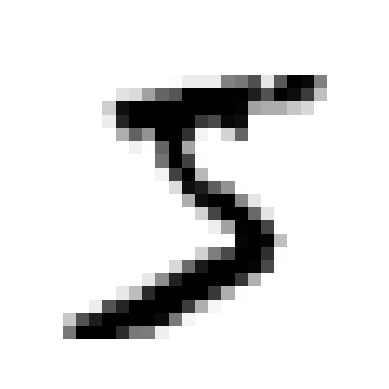

'5'

In [17]:
digit = X.iloc[0]
some_digit_image = digit.to_numpy().reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

y.iloc[0]

In [22]:
y = y.astype(np.uint8)
X_train,X_test,y_train,y_test = X[:60000], X[60000:], y[:60000], y[60000:]

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([digit])


/home/raf75/sexto-periodo/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

# Prever digitos (0–9) a partir de imagem
Passos:
1. Treinar um classificador multiclasses (0 a 9).
2. Preprocessar a imagem para 28x28 em tons de cinza.
3. Usar o modelo para prever o digito.

Se precisar instalar o Pillow: `pip install pillow`

In [29]:
# Classificador multiclasses (0-9)
sgd_clf_digits = SGDClassifier(random_state=42)
sgd_clf_digits.fit(X_train, y_train)
sgd_clf_digits.predict([digit])

/home/raf75/sexto-periodo/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [32]:
import ipywidgets as widgets
from IPython.display import display

display(widgets.FileUpload(accept="image/*", multiple=False))

FileUpload(value=(), accept='image/*', description='Upload')

In [31]:
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(uploader)

def _predict_from_upload(change):
    if not uploader.value:
        return
    # Pega o primeiro arquivo enviado
    uploaded = next(iter(uploader.value.values()))
    content = uploaded["content"]
    img = Image.open(io.BytesIO(content)).convert("L").resize((28, 28))
    img_array = np.array(img, dtype=np.uint8)
    if img_array.mean() > 127:
        img_array = 255 - img_array
    sample = img_array.reshape(1, 784)
    pred = sgd_clf_digits.predict(sample)[0]
    print("Predicao:", pred)

uploader.observe(_predict_from_upload, names="value")

FileUpload(value=(), accept='image/*', description='Upload')